# Fisher information in JAISP — a field guide

Fisher information formalizes "how much does the data constrain a parameter": for a
position measurement with error $\sigma$, the information is $1/\sigma^2$, and independent
measurements *add* in that currency. This notebook distills how to use it correctly in
JAISP, from a first round of experiments (earlier versions of this notebook, nb26, nb27)
that produced both real results and instructive failures. Three rules organize everything:

**Rule 1 — Fisher is conditional on the data model; walk the ladder before trusting a
number.** Every Fisher value answers "how much information exists *given this model of
signal and noise*." The same question asked three ways gave three different answers here:
idealized injections (equal peak SNR in all ten bands, WCS treated as truth) say the ten
bands carry ×5.5 the VIS-only information; real SEDs shrink that to ×2.2 (a ×1.47 error
reduction); real-sky error correlations (the paper's concordance field, seen per-source)
leave nearly nothing collectible at the bright end and ~15% at the faint end. None of
these numbers is wrong — each is the right answer to a progressively more honest question.
Never treat a rung's number as a target until the noise model includes your systematics.

**Rule 2 — use the analytic pixel CRB as a ceiling and a falsifier, not Monte Carlo.**
With a known source model and variance maps, the pixel-level Cramér–Rao bound is an exact
sum — no simulations. It bounds every downstream quantity (data-processing inequality), so
any estimate that beats it is broken. That tripwire caught a real bug here: a
Monte-Carlo Fisher estimator for latent representations that manufactured information from
noise (demonstrated below). Corollary: **never quote a Fisher-like estimate of a learned
representation without running its zero-signal null.**

**Rule 3 — to measure information in a representation, extract it.** Train a simple
decoder on realizations with known truth and score its held-out error. An actual
estimator's scatter is a valid, assumption-free information lower bound — it can only
understate. Two sub-lessons: regularized decoders shrink toward the training prior
(calibrate the slope before comparing or combining), and empirical estimator scatter (not
estimated Fisher) is the honest currency for anything learned.

Section map: §1 the exact tool (pixel CRB, rungs 1–2 of the ladder) · §2 estimators
against bounds (head, classical, joint fit; independence and the addition law) · §3 the
cautionary tale (why we do not Fisher-estimate latents) · §4 the decoder bound (the honest
instrument; full ten-band version in nb26) · §5 rung 3, real sky (the concordance field as
a correlation matrix; pooling consequences in nb27) · §6 the ladder, assembled.

In [1]:
import sys, json, time
from pathlib import Path

def find_repo_root(s=None):
    s = (s or Path.cwd()).resolve()
    for c in [s, *s.parents]:
        if (c/'models').exists() and (c/'data').exists():
            return c
    raise FileNotFoundError('repo root')

REPO = find_repo_root()
for p in (REPO/'models', REPO, REPO/'models'/'astrometry2'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io import fits
from scipy.spatial import cKDTree
from scipy.optimize import least_squares

from astrometry2.latent_position_head import load_latent_position_head, extract_local_windows
from astrometry2.source_matching import safe_header_from_card_string
from astrometry2.dataset import (build_full_context_detector_inputs,
                                 refine_centroids_psf_fit, local_vis_pixel_to_sky_matrix)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
OUT = REPO/'io'/'_nb25_outputs'
OUT.mkdir(exist_ok=True)

FOUNDATION = REPO/'models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt'
HEAD_CKPT  = REPO/'models/checkpoints/latent_position_q1_vissep_patchval25/best.pt'  # patch-disjoint

CFG = dict(tile_index=0, n_src=16, snr=10.0, n_center=128, seed=20260811)
SIGMA_PX = {'VIS': 2.5/2.355, 'NISP': 2.5/2.355, 'RUBIN': 3.0/2.355}
RUBIN_BANDS = ['u','g','r','i','z','y']
NISP_BANDS  = ['Y','J','H']
VIS_MAS, RUBIN_MAS = 100.0, 200.0

# frozen encoder + patch-disjoint position head
ck = torch.load(HEAD_CKPT, map_location='cpu', weights_only=False)
hcfg = ck.get('config', {})
fe, head = load_latent_position_head(str(FOUNDATION), device=DEVICE,
                                     bottleneck_window=hcfg.get('bottleneck_window', 5) or 5,
                                     stem_window=hcfg.get('stem_window', 17) or 17)
head.load_state_dict(ck['head_state_dict'])
head.eval()

# one held-out patch-25 tile
rdir, edir = REPO/'data/rubin_tiles_patch25', REPO/'data/euclid_tiles_all_q1'
stem = sorted(p.name[:-4] for p in rdir.glob('tile_*.npz'))[CFG['tile_index']]
rdata = dict(np.load(rdir/f'{stem}.npz', allow_pickle=True))
edata = dict(np.load(edir/f'{stem}_euclid.npz', allow_pickle=True))
vwcs = WCS(safe_header_from_card_string(edata['wcs_VIS'].item()))
rwcs = WCS(rdata['wcs_hdr'].item())
base_images, tile_rms, vis_hw = build_full_context_detector_inputs(
    edata, rdata['img'], rubin_var=rdata.get('var'))
H, W = vis_hw
rms_t = {b: torch.from_numpy(r[None, None].copy()).float().to(DEVICE) for b, r in tile_rms.items()}

BAND_INFO = {}   # band -> (wcs, mas per native px, injected gaussian sigma in px)
for b in ['VIS'] + NISP_BANDS:
    w = vwcs if b == 'VIS' else WCS(safe_header_from_card_string(edata[f'wcs_{b}'].item()))
    BAND_INFO[f'euclid_{b}'] = (w, VIS_MAS, SIGMA_PX['VIS' if b == 'VIS' else 'NISP'])
for b in RUBIN_BANDS:
    BAND_INFO[f'rubin_{b}'] = (rwcs, RUBIN_MAS, SIGMA_PX['RUBIN'])

# injection sites: random sub-pixel, away from real sources and edges
LAB = torch.load(REPO/'data/detection_labels/centernet_q1_790_vissep_thresh03.pt',
                 map_location='cpu', weights_only=False)
LAB = LAB['labels'] if 'labels' in LAB else LAB
rng = np.random.default_rng(CFG['seed'])
ent_ = LAB[stem]
xy_norm = np.asarray(ent_[0] if isinstance(ent_, tuple) else ent_, dtype=np.float32)
tree = cKDTree(np.stack([xy_norm[:, 0]*(W-1), xy_norm[:, 1]*(H-1)], axis=1))
pts = []
while len(pts) < CFG['n_src']:
    x, y = rng.uniform(120, W-120), rng.uniform(120, H-120)
    if np.isfinite(tree.query([[x, y]], distance_upper_bound=25.0)[0][0]):
        continue
    if pts and np.min(np.hypot(*(np.asarray(pts) - [x, y]).T)) < 80:
        continue
    pts.append([x, y])
pts = np.asarray(pts, np.float32)
ra0, dec0 = vwcs.pixel_to_world_values(pts[:, 0], pts[:, 1])
pix2sky = np.stack([local_vis_pixel_to_sky_matrix(vwcs, p) for p in pts]).astype(np.float32)
print(DEVICE, '|', stem, '|', len(pts), 'injection sites')

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt
  bottleneck_window=5  (physical coverage: 2.0" at 0.40"/px)
LatentPositionHead: 0.69M trainable, 7.3M frozen encoder  (v10 foundation)


cuda:0 | tile_x00000_y00000_tract5063_patch_25 | 16 injection sites


## §1 The exact tool: the pixel-level Cramér–Rao bound

For a point source with known profile $m$ injected into noise with known variance, the
per-axis Fisher information is an exact sum, $F=\sum_{\rm pix}(\partial m/\partial x)^2/
\sigma^2_{\rm pix}$ — no Monte Carlo. Three properties make it the workhorse:

- **At fixed *peak* SNR it is nearly PSF-width independent** (a wider PSF spreads the
  gradient over more pixels), so per-band comparisons are clean.
- **Bands add in Fisher** (independent noise): convert each band to sky units
  (mas$^{-2}$) and sum.
- **It is the data-processing ceiling**: any deterministic function of the pixels — stem,
  bottleneck, head — carries at most this much information. Anything downstream that
  "beats" it is a bug detector firing.

The cell also cross-checks the analytic formula by finite differences of the *actual*
injected images (same WCS chain, same sampling): a habit worth keeping, since a wrong
ceiling silently invalidates every comparison against it.

**Rung 1 of the ladder** is the printout: at equal peak SNR 10 in every band, all ten
bands carry $\sigma=3.40$ mas versus VIS-only 7.98 — ×5.5 in information. Conditional on
the idealization. **Rung 2** re-asks with real amplitudes: the per-band peak SNRs of 1,710
real sources (measured in nb26) turn ×5.5 into ×2.2 (median error shrink ×1.47), with the
non-VIS information concentrated in Rubin $g/r/i$.

ceiling cross-check (rubin_r, source 0): analytic 15.96 vs FD 15.94 mas

RUNG 1 (idealized: equal peak SNR 10, WCS = truth; per-axis, median):
  VIS only      : sigma_CRB =  7.98 mas
  Euclid 4-band : sigma_CRB =  3.99 mas
  Rubin 6-band  : sigma_CRB =  6.51 mas
  all 10 bands  : sigma_CRB =  3.40 mas


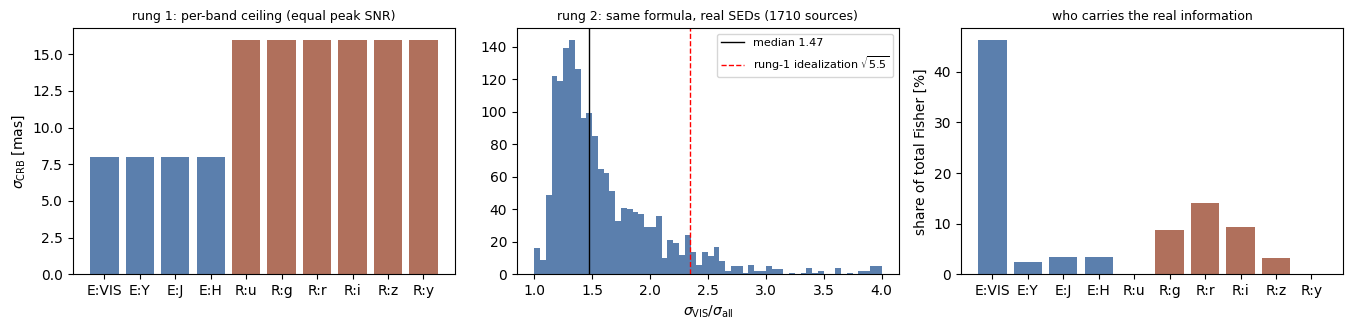

RUNG 2 (real SEDs): median headroom x1.47 in sigma (x2.2 in information); VIS 46%, Rubin g+r+i 32%


In [2]:
def local_rms(rms_img, x, y):
    xi = int(np.clip(round(float(x)), 0, rms_img.shape[1]-1))
    yi = int(np.clip(round(float(y)), 0, rms_img.shape[0]-1))
    v = float(rms_img[yi, xi])
    return v if np.isfinite(v) and v > 0 else float(np.nanmedian(rms_img))

def pixel_fisher_band(amp, x, y, sigma, var_local):
    # per-axis Fisher (band px^-2), Gaussian sampled at pixel centres at the true phase
    r = int(max(8, np.ceil(5*sigma)))
    yy, xx = np.mgrid[-r:r+1, -r:r+1].astype(np.float64)
    xx += (x - round(x)); yy += (y - round(y))
    g = np.exp(-0.5*(xx**2 + yy**2)/sigma**2)
    return float(((amp*(xx/sigma**2)*g)**2).sum()/var_local)

def inject_gauss(img, x, y, sigma, amp):    # float sub-pixel centre (nb09 convention)
    Hh, Ww = img.shape
    r = int(max(6, np.ceil(4*sigma)))
    x0, x1 = max(0, int(x)-r), min(Ww, int(x)+r+1)
    y0, y1 = max(0, int(y)-r), min(Hh, int(y)+r+1)
    yy, xx = np.mgrid[y0:y1, x0:x1]
    img[y0:y1, x0:x1] += (amp*np.exp(-0.5*(((xx-x)/sigma)**2 + ((yy-y)/sigma)**2))).astype(img.dtype)

BPX0, F_pix = {}, {}
for band, (bw, scale_mas, sig) in BAND_INFO.items():
    bx, by = bw.world_to_pixel_values(ra0, dec0)
    BPX0[band] = np.stack([bx, by], axis=1).astype(np.float32)
    F = np.zeros(len(pts))
    for k in range(len(pts)):
        r = local_rms(tile_rms[band], bx[k], by[k])
        F[k] = pixel_fisher_band(CFG['snr']*r, bx[k], by[k], sig, r*r)/scale_mas**2
    F_pix[band] = F

F_pix_vis = F_pix['euclid_VIS']
F_pix_all = np.sum([F_pix[b] for b in F_pix], axis=0)

# cross-check the analytic ceiling by finite differences of ACTUAL injected images
band, (bw, scale_mas, sig) = 'rubin_r', BAND_INFO['rubin_r']
k0, dlt = 0, 0.25
Ffd = np.zeros(2)
for a, (dx, dy) in enumerate([(dlt, 0), (0, dlt)]):
    dp, dm = np.zeros_like(base_images[band]), np.zeros_like(base_images[band])
    for sgn, tgt in [(+1, dp), (-1, dm)]:
        ra_, dec_ = vwcs.pixel_to_world_values(pts[k0, 0]+sgn*dx, pts[k0, 1]+sgn*dy)
        bx_, by_ = bw.world_to_pixel_values(ra_, dec_)
        inject_gauss(tgt, float(bx_), float(by_), sig,
                     CFG['snr']*local_rms(tile_rms[band], float(bx_), float(by_)))
    g = (dp-dm)/(2*dlt)
    Ffd[a] = (g**2/np.clip(tile_rms[band], 1e-12, None)**2).sum()/VIS_MAS**2 * (VIS_MAS/VIS_MAS)**2
sig_fd = float(np.mean(1/np.sqrt(Ffd)))
sig_an = 1/np.sqrt(F_pix['rubin_r'][k0])
assert abs(sig_fd - sig_an)/sig_an < 0.05, (sig_fd, sig_an)
print(f'ceiling cross-check (rubin_r, source 0): analytic {sig_an:.2f} vs FD {sig_fd:.2f} mas')

print(f'\nRUNG 1 (idealized: equal peak SNR {CFG["snr"]:.0f}, WCS = truth; per-axis, median):')
for name, F in [('VIS only', F_pix_vis),
                ('Euclid 4-band', np.sum([F_pix[b] for b in F_pix if b.startswith('euclid')], 0)),
                ('Rubin 6-band', np.sum([F_pix[b] for b in F_pix if b.startswith('rubin')], 0)),
                ('all 10 bands', F_pix_all)]:
    print(f'  {name:14s}: sigma_CRB = {np.median(1/np.sqrt(F)):5.2f} mas')

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
order = list(BAND_INFO)
axes[0].bar(range(len(order)), [np.median(1/np.sqrt(F_pix[b])) for b in order],
            color=['#5b7fad' if b.startswith('euclid') else '#b0705c' for b in order])
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels([b.replace('euclid_', 'E:').replace('rubin_', 'R:') for b in order])
axes[0].set_ylabel(r'$\sigma_{\rm CRB}$ [mas]'); axes[0].set_title('rung 1: per-band ceiling (equal peak SNR)', fontsize=9)

# RUNG 2: the same formula fed real per-band amplitudes (census computed in nb26)
sed = np.load(REPO/'io/_nb26_outputs/step0_sed_census.npz', allow_pickle=True)
Fm, bands26 = np.asarray(sed['F']), list(sed['bands'])
vis_i = bands26.index('euclid_VIS')
good = Fm[:, vis_i] > 0
headroom = np.sqrt(Fm[good].sum(1)/Fm[good, vis_i])
axes[1].hist(headroom, bins=np.linspace(1, 4, 61), color='#5b7fad')
axes[1].axvline(np.median(headroom), c='k', lw=1, label=f'median {np.median(headroom):.2f}')
axes[1].axvline(np.sqrt(5.5), c='r', ls='--', lw=1, label=r'rung-1 idealization $\sqrt{5.5}$')
axes[1].set_xlabel(r'$\sigma_{\rm VIS}/\sigma_{\rm all}$'); axes[1].legend(fontsize=8)
axes[1].set_title('rung 2: same formula, real SEDs (1710 sources)', fontsize=9)
frac = np.median(Fm[good]/Fm[good].sum(1)[:, None], axis=0)
axes[2].bar(range(len(bands26)), 100*frac,
            color=['#5b7fad' if b.startswith('euclid') else '#b0705c' for b in bands26])
axes[2].set_xticks(range(len(bands26)))
axes[2].set_xticklabels([b.replace('euclid_', 'E:').replace('rubin_', 'R:') for b in bands26])
axes[2].set_ylabel('share of total Fisher [%]'); axes[2].set_title('who carries the real information', fontsize=9)
plt.tight_layout(); plt.show()
print(f'RUNG 2 (real SEDs): median headroom x{np.median(headroom):.2f} in sigma '
      f'(x{np.median(headroom)**2:.1f} in information); VIS {100*frac[vis_i]:.0f}%, '
      f'Rubin g+r+i {100*sum(frac[bands26.index(b)] for b in ["rubin_g","rubin_r","rubin_i"]):.0f}%')

## §2 Estimators against bounds

Fisher gives the ceiling; only an estimator's *measured scatter* says what is achieved.
The engine: the real tile is a frozen scene, sources are injected at known sub-pixel truth
in all ten bands, and each realization adds **fresh noise drawn from the variance maps** —
the same noise that defines the CRB, so bounds and estimators face one identical noise
model. Per-source scatter across realizations counts only fresh-noise sensitivity; the
frozen scene contributes a per-source bias, reported separately.

Four estimators on identical paired realizations:
1. **classical VIS centroid** (production baseline),
2. **the position head** (bottleneck + VIS stem),
3. **a joint 10-band $\chi^2$ fit** — one shared sky position against all ten stamps
   (per-band amplitude and background profiled out) — the estimator that should reach the
   all-band ceiling if the information is real and independent,
4. **inverse-variance combination of ten single-band fits**, which tests the addition law
   directly, alongside the 10×10 inter-band error correlation matrix (independence).

Reading the result: the head sits *exactly on the VIS ceiling* — it is optimal for its
inputs, and its gap to 3.4 mas is architectural (it does not read the other bands' stems),
not a training deficiency. The joint fit drains the bucket, the errors are independent,
and informations add — on injections, where WCS is truth. The head's predicted $\sigma$ is
overconfident here by ~1.7 (compare nb24's bright-star $\alpha$): predicted uncertainties
are inputs to calibration, never substitutes for measured scatter.

  encode 32/128  (0.9 min)


  encode 64/128  (1.8 min)


  encode 96/128  (2.6 min)


  encode 128/128  (3.5 min)


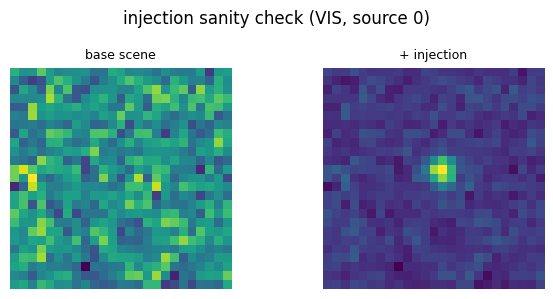

In [3]:
# noiseless injection delta per band (center position only -- no FD shifts needed here)
DELTA_C = {}
for band, (bw, scale_mas, sig) in BAND_INFO.items():
    delta = np.zeros_like(base_images[band])
    for k in range(len(pts)):
        amp = CFG['snr']*local_rms(tile_rms[band], BPX0[band][k, 0], BPX0[band][k, 1])
        inject_gauss(delta, float(BPX0[band][k, 0]), float(BPX0[band][k, 1]), sig, amp)
    DELTA_C[band] = delta

pos_vis_t = torch.from_numpy(pts).float().to(DEVICE)
pix2sky_t = torch.from_numpy(pix2sky).to(DEVICE)
pix2sky_inv = np.linalg.inv(pix2sky)

@torch.no_grad()
def run_estimators(noise_seed):
    r = np.random.default_rng(noise_seed)
    imgs, img_t = {}, {}
    for band in base_images:                      # NOTE: iteration order defines the seed stream
        img = (base_images[band] + DELTA_C[band]
               + r.standard_normal(base_images[band].shape).astype(np.float32)*tile_rms[band])
        imgs[band] = img
        img_t[band] = torch.from_numpy(img[None, None]).to(DEVICE)
    enc = fe.encoder(img_t, rms_t)
    vis_stem = fe.vis_stem(img_t['euclid_VIS'], rms_t['euclid_VIS'])
    h = head(enc['bottleneck'], vis_stem, pos_vis_t, pix2sky_t, enc['fused_hw'], vis_hw)
    pred_px = np.einsum('nij,nj->ni', pix2sky_inv, h['pred_offset_arcsec'].cpu().numpy())
    cxy, _, _ = refine_centroids_psf_fit(imgs['euclid_VIS'], pts.copy(), radius=3, fwhm_guess=2.5)
    return pts + pred_px, np.exp(h['log_sigma'].cpu().numpy()), np.asarray(cxy, np.float32)

HEADXY, SIGP, CLSXY = [], [], []
t0 = time.time()
for i in range(CFG['n_center']):
    hxy, sp, cxy = run_estimators(CFG['seed']+i)
    HEADXY.append(hxy); SIGP.append(sp); CLSXY.append(cxy)
    if (i+1) % 32 == 0:
        print(f'  encode {i+1}/{CFG["n_center"]}  ({(time.time()-t0)/60:.1f} min)', flush=True)
HEADXY, SIGP, CLSXY = np.stack(HEADXY), np.stack(SIGP), np.stack(CLSXY)

k0 = 0
sl = np.s_[int(pts[k0, 1])-12:int(pts[k0, 1])+13, int(pts[k0, 0])-12:int(pts[k0, 0])+13]
fig, axes = plt.subplots(1, 2, figsize=(6.4, 3))
for ax, (t_, im) in zip(axes, [('base scene', base_images['euclid_VIS'][sl]),
                               ('+ injection', (base_images['euclid_VIS']+DELTA_C['euclid_VIS'])[sl])]):
    ax.imshow(im, origin='lower'); ax.set_title(t_, fontsize=9); ax.axis('off')
plt.suptitle('injection sanity check (VIS, source 0)'); plt.tight_layout(); plt.show()

In [4]:
# joint and single-band chi2 fits on the SAME noise realizations (paired seeds)
R_STAMP = {b: (9 if b.startswith('euclid') else 6) for b in BAND_INFO}
A_MAP = {}
for band, (bw, scale_mas, sig) in BAND_INFO.items():
    A = np.zeros((len(pts), 2, 2))
    for a in range(2):
        e = np.eye(2)[a]
        ra_e, dec_e = vwcs.pixel_to_world_values(pts[:, 0]+e[0], pts[:, 1]+e[1])
        bx_e, by_e = bw.world_to_pixel_values(ra_e, dec_e)
        A[:, 0, a] = bx_e - BPX0[band][:, 0]
        A[:, 1, a] = by_e - BPX0[band][:, 1]
    A_MAP[band] = A

def band_stamp(img, band, k):
    R = R_STAMP[band]
    cx, cy = BPX0[band][k]
    x0, y0 = int(round(float(cx)))-R, int(round(float(cy)))-R
    return img[y0:y0+2*R+1, x0:x0+2*R+1], x0, y0

FIT_CTX = {}
for band in BAND_INFO:
    for k in range(len(pts)):
        st_rms, x0, y0 = band_stamp(tile_rms[band], band, k)
        yy, xx = np.mgrid[y0:y0+st_rms.shape[0], x0:x0+st_rms.shape[1]]
        FIT_CTX[band, k] = (xx.astype(np.float64), yy.astype(np.float64),
                            (1.0/np.clip(st_rms, 1e-12, None)**2).astype(np.float64))

def chi_residuals(dxy, stamps, bands, k):
    res = []
    for band, st in zip(bands, stamps):
        xx, yy, w = FIT_CTX[band, k]
        sig = BAND_INFO[band][2]
        c = BPX0[band][k] + A_MAP[band][k] @ dxy
        g = np.exp(-0.5*(((xx-c[0])/sig)**2 + ((yy-c[1])/sig)**2))
        M = np.stack([g.ravel(), np.ones(g.size)], axis=1)
        Wv = w.ravel()
        coef = np.linalg.solve(M.T @ (M*Wv[:, None]), M.T @ (Wv*st.ravel()))
        res.append((st.ravel() - M @ coef)*np.sqrt(Wv))
    return np.concatenate(res)

def fit_position(stamps, bands, k):
    try:
        return least_squares(chi_residuals, [0.0, 0.0], args=(stamps, bands, k),
                             bounds=(-3, 3), diff_step=0.05).x
    except Exception:
        return np.array([np.nan, np.nan])

ALL_BANDS = list(BAND_INFO)
xy_joint = np.zeros((CFG['n_center'], len(pts), 2))
xy_band = np.zeros((CFG['n_center'], len(ALL_BANDS), len(pts), 2))
t0 = time.time()
for i in range(CFG['n_center']):
    r = np.random.default_rng(CFG['seed']+i)
    imgs = {}
    for band in base_images:                      # same order as run_estimators -> same noise
        imgs[band] = (base_images[band] + DELTA_C[band]
                      + r.standard_normal(base_images[band].shape).astype(np.float32)*tile_rms[band])
    for k in range(len(pts)):
        stamps = [band_stamp(imgs[b], b, k)[0].astype(np.float64) for b in ALL_BANDS]
        xy_joint[i, k] = fit_position(stamps, ALL_BANDS, k)
        for bi, b in enumerate(ALL_BANDS):
            xy_band[i, bi, k] = fit_position([stamps[bi]], [b], k)
    if (i+1) % 32 == 0:
        print(f'  fits {i+1}/{CFG["n_center"]}  ({(time.time()-t0)/60:.1f} min)', flush=True)

  fits 32/128  (0.3 min)


  fits 64/128  (0.6 min)


  fits 96/128  (0.8 min)


  fits 128/128  (1.0 min)


per-axis scatter vs the ceilings (median over 16 sources, mas):
  VIS pixel CRB (ceiling)        7.98
  classical VIS centroid         8.06
  position head                  7.69   (predicted sigma 4.58 -> overconfident x1.7)
  VIS single-band fit            7.82
  all-band pixel CRB (ceiling)   3.40
  joint 10-band fit              3.42
  IV combo of 10 fits            3.40   (addition-law prediction 3.41)
  inter-band error correlations: median |off-diag| = 0.014 (independent)


/home/shemmati/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/shemmati/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


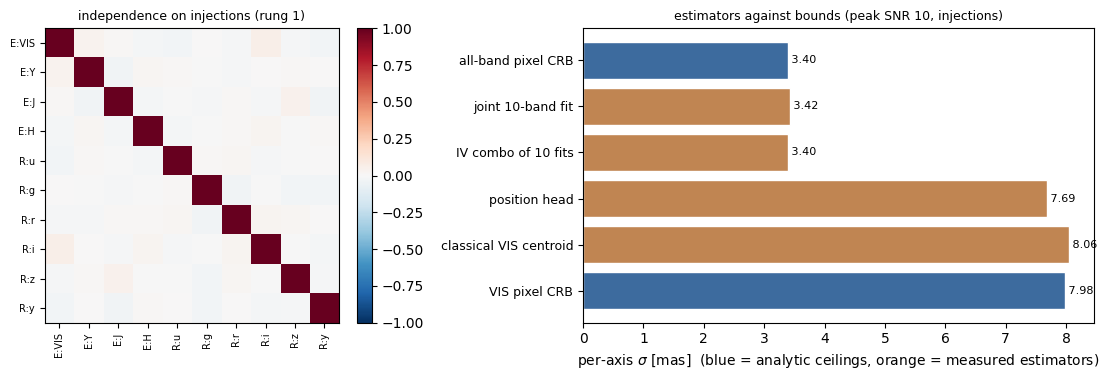

In [5]:
# the estimator table, independence matrix, and addition law
sig_cls = np.sqrt(np.nanvar(CLSXY, axis=0).mean(-1))*VIS_MAS
sig_head = np.sqrt(HEADXY.var(axis=0).mean(-1))*VIS_MAS
sig_joint = np.sqrt(np.nanvar(xy_joint, axis=0).mean(-1))*VIS_MAS
sig_band = np.sqrt(np.nanvar(xy_band, axis=0).mean(-1))*VIS_MAS
w_ = 1.0/np.nanvar(xy_band, axis=0).mean(-1)
combo = np.nansum(xy_band*w_[None, :, :, None], axis=1)/np.nansum(w_, axis=0)[None, :, None]
sig_combo = np.sqrt(np.nanvar(combo, axis=0).mean(-1))*VIS_MAS
sig_pred_add = 1.0/np.sqrt(np.nansum(1.0/sig_band**2, axis=0))

vis_bi = ALL_BANDS.index('euclid_VIS')
print(f'per-axis scatter vs the ceilings (median over {len(pts)} sources, mas):')
print(f'  VIS pixel CRB (ceiling)      {np.median(1/np.sqrt(F_pix_vis)):6.2f}')
print(f'  classical VIS centroid       {np.nanmedian(sig_cls):6.2f}')
print(f'  position head                {np.median(sig_head):6.2f}   (predicted sigma {np.median(SIGP)*1000:.2f} -> overconfident x{np.median(sig_head)/(np.median(SIGP)*1000):.1f})')
print(f'  VIS single-band fit          {np.nanmedian(sig_band[vis_bi]):6.2f}')
print(f'  all-band pixel CRB (ceiling) {np.median(1/np.sqrt(F_pix_all)):6.2f}')
print(f'  joint 10-band fit            {np.nanmedian(sig_joint):6.2f}')
print(f'  IV combo of 10 fits          {np.nanmedian(sig_combo):6.2f}   (addition-law prediction {np.nanmedian(sig_pred_add):.2f})')

C_acc = []
for k in range(len(pts)):
    for a in (0, 1):
        E = xy_band[:, :, k, a]
        ok = np.isfinite(E).all(1)
        if ok.sum() > 8:
            C_acc.append(np.corrcoef(E[ok].T))
C_med = np.nanmedian(np.stack(C_acc), axis=0)
off = C_med[~np.eye(len(ALL_BANDS), dtype=bool)]
print(f'  inter-band error correlations: median |off-diag| = {np.median(np.abs(off)):.3f} (independent)')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), gridspec_kw={'width_ratios': [1, 1.4]})
im = axes[0].imshow(C_med, vmin=-1, vmax=1, cmap='RdBu_r')
short = [b.replace('euclid_', 'E:').replace('rubin_', 'R:') for b in ALL_BANDS]
axes[0].set_xticks(range(len(short))); axes[0].set_xticklabels(short, rotation=90, fontsize=7)
axes[0].set_yticks(range(len(short))); axes[0].set_yticklabels(short, fontsize=7)
axes[0].set_title('independence on injections (rung 1)', fontsize=9)
plt.colorbar(im, ax=axes[0], fraction=0.046)
names = ['all-band pixel CRB', 'joint 10-band fit', 'IV combo of 10 fits',
         'position head', 'classical VIS centroid', 'VIS pixel CRB']
vals = [np.median(1/np.sqrt(F_pix_all)), np.nanmedian(sig_joint), np.nanmedian(sig_combo),
        np.median(sig_head), np.nanmedian(sig_cls), np.median(1/np.sqrt(F_pix_vis))]
cols = ['#3d6b9e', '#c08552', '#c08552', '#c08552', '#c08552', '#3d6b9e']
yp = np.arange(len(names))[::-1]
for yi, n_, v, c in zip(yp, names, vals, cols):
    axes[1].barh(yi, v, color=c, edgecolor='white')
    axes[1].text(v, yi, f' {v:.2f}', va='center', fontsize=8)
axes[1].set_yticks(yp); axes[1].set_yticklabels(names, fontsize=9)
axes[1].set_xlabel(r'per-axis $\sigma$ [mas]  (blue = analytic ceilings, orange = measured estimators)')
axes[1].set_title('estimators against bounds (peak SNR 10, injections)', fontsize=9)
plt.tight_layout(); plt.savefig(OUT/'fisher_estimators_vs_bounds.png', dpi=150); plt.show()

## §3 The anti-tool: do not Fisher-estimate learned representations

The tempting recipe — estimate the latent's response Jacobian $J$ and noise covariance
$C$ from realizations, quote $J^\top C^{-1}J$ — **fails at any realistic realization
budget**, and fails in the dangerous direction (too much information). Mechanism: the
finite-sample noise in $\hat J$ enters the quadratic form as $|J_{\rm noise}|^2$ summed
over the effective rank of the window covariance; with ~10² realizations against 10³–10⁴
latent dimensions this fabricates "information" comparable to or exceeding real signals.
Projections, Hartlap corrections, and split-half cross-estimators do not rescue it (the
basis selection double-dips). In the first version of this notebook the fabricated
information *exceeded the pixel ceiling* for the Rubin stems — which is how Rule 2's
tripwire caught it.

The demonstration below runs the estimator twice on the `rubin_r` stem: once with a real
±25 mas source shift, once with **zero true shift** (only the seeds differ). The null
reports several-mas-level "information" from pure noise, at the same scale as the real
measurement. **The rule: any Fisher-like estimate of a representation is inadmissible
without its zero-signal null — and if the null is not orders of magnitude weaker, use the
decoder bound of §4 instead.**

In [6]:
band, WSZ, dlt, NJ, NC = 'rubin_r', 9, 0.25, 8, 96
bw, scale_mas, sig = BAND_INFO[band]
def delta_for(dx, dy):
    ra_, dec_ = vwcs.pixel_to_world_values(pts[:, 0]+dx, pts[:, 1]+dy)
    bx_, by_ = bw.world_to_pixel_values(ra_, dec_)
    dd = np.zeros_like(base_images[band])
    for k in range(len(pts)):
        inject_gauss(dd, float(bx_[k]), float(by_[k]), sig,
                     CFG['snr']*local_rms(tile_rms[band], bx_[k], by_[k]))
    return dd
DELT = {t: delta_for(dx, dy) for t, (dx, dy) in
        {'c': (0, 0), '+x': (dlt, 0), '-x': (-dlt, 0), '+y': (0, dlt), '-y': (0, -dlt)}.items()}
pos_b = torch.from_numpy(BPX0[band]).float().to(DEVICE)

@torch.no_grad()
def stem_win(tag, seed):
    r = np.random.default_rng(seed)
    img = base_images[band] + DELT[tag] + r.standard_normal(base_images[band].shape).astype(np.float32)*tile_rms[band]
    sm = fe.encoder.stems[band](torch.from_numpy(img[None, None]).to(DEVICE), rms_t[band])
    return extract_local_windows(sm, pos_b, WSZ).reshape(len(pts), -1).float().cpu().numpy()

Zc = np.stack([stem_win('c', CFG['seed']+i) for i in range(NC)])
Zs = {t: np.stack([stem_win(t, CFG['seed']+200000+i) for i in range(NJ)])   # CRN across tags
      for t in ['+x', '-x', '+y', '-y']}
Zn = {t: np.stack([stem_win('c', CFG['seed']+off+i) for i in range(NJ)])
      for t, off in [('a', 300000), ('b', 400000), ('e', 500000), ('f', 600000)]}
J_real = np.stack([(Zs['+x']-Zs['-x']).mean(0)/(2*dlt), (Zs['+y']-Zs['-y']).mean(0)/(2*dlt)], -1)
J_null = np.stack([(Zn['a']-Zn['b']).mean(0)/(2*dlt), (Zn['e']-Zn['f']).mean(0)/(2*dlt)], -1)

def fisher_est(X, Jk, n_pc):
    Xc = X - X.mean(0); N = X.shape[0]; B = Jk
    if n_pc:
        _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
        B = np.concatenate([B, Vt[:n_pc].T], 1)
    Q, _ = np.linalg.qr(B); p = Q.shape[1]
    T = Xc @ Q; C = np.cov(T, rowvar=False)
    M = Q.T @ Jk
    return M.T @ (((N-p-2)/(N-1))*np.linalg.inv(np.atleast_2d(C))) @ M

def sig_eq(F):
    ev = np.linalg.eigvalsh(np.asarray(F, np.float64))
    return np.nan if ev.min() <= 0 else float(np.prod(1/ev)**0.25)*VIS_MAS

print(f'{band} stem, pixel ceiling {np.median(1/np.sqrt(F_pix[band])):.1f} mas:')
for kk in [0, 32]:
    s_r = np.nanmedian([sig_eq(fisher_est(Zc[:, k], J_real[k], kk)) for k in range(len(pts))])
    s_n = np.nanmedian([sig_eq(fisher_est(Zc[:, k], J_null[k], kk)) for k in range(len(pts))])
    print(f'  +{kk:2d} PCA modes: real shift -> "{s_r:5.1f} mas"   ZERO shift -> "{s_n:5.1f} mas"  <- fabricated')
print('the null is not orders of magnitude weaker: this estimator is inadmissible here.')

rubin_r stem, pixel ceiling 16.0 mas:
  + 0 PCA modes: real shift -> " 17.6 mas"   ZERO shift -> " 17.1 mas"  <- fabricated


  +32 PCA modes: real shift -> " 11.2 mas"   ZERO shift -> "  8.0 mas"  <- fabricated
the null is not orders of magnitude weaker: this estimator is inadmissible here.


## §4 The honest instrument: the decoder bound

To measure the information a representation retains, **build an estimator and score it**:
train a linear (ridge) reader from the representation to the injected offset on
realizations with random sub-pixel truth, and measure its held-out error. The scatter of
a real estimator is a valid lower bound on the information with no Jacobians, no
covariance inversions, no Gaussian assumptions — bias direction guaranteed conservative.

One correction is mandatory: a regularized reader shrinks toward the training prior
(offsets uniform ±0.5 px → prior $\sigma$ 28.9 mas/axis), which lets it apparently beat
the frequentist CRB per band and — worse — injects a *shared* bias into any cross-band
combination. Report the information-corrected value
$1/\sigma_{\rm info}^2 = 1/\sigma_{\rm meas}^2 - 1/\sigma_{\rm prior}^2$, and slope-
calibrate on validation before combining.

The demo below runs two stems (VIS and `rubin_r`); the full ten-band gate lives in nb26:
every stem retains 80–85% of its band's pixel information, and ten calibrated linear
readers combine to **3.96 mas** vs the 3.40 ceiling — the measured basis for the
multi-band head design.

In [7]:
DEC_BANDS = ['euclid_VIS', 'rubin_r']
N_REAL, NTR, NVA = 320, 220, 50           # remaining 50 = test
PRIOR_STD_MAS = VIS_MAS*0.5/np.sqrt(3.0)
WS_DEC = {'euclid_VIS': 11, 'rubin_r': 9}
Xd = {b: np.zeros((N_REAL, len(pts), WS_DEC[b]**2*64), np.float16) for b in DEC_BANDS}
Yofs = np.zeros((N_REAL, len(pts), 2), np.float32)
t0 = time.time()
for i in range(N_REAL):
    r = np.random.default_rng(CFG['seed']+700000+i)
    offs = r.uniform(-0.5, 0.5, size=(len(pts), 2)).astype(np.float32)
    Yofs[i] = offs
    ra_, dec_ = vwcs.pixel_to_world_values(pts[:, 0]+offs[:, 0], pts[:, 1]+offs[:, 1])
    for b in DEC_BANDS:
        bw, scale_mas, sig = BAND_INFO[b]
        bx_, by_ = bw.world_to_pixel_values(ra_, dec_)
        img = base_images[b] + r.standard_normal(base_images[b].shape).astype(np.float32)*tile_rms[b]
        for k in range(len(pts)):
            inject_gauss(img, float(bx_[k]), float(by_[k]), sig,
                         CFG['snr']*local_rms(tile_rms[b], bx_[k], by_[k]))
        with torch.no_grad():
            sm = fe.encoder.stems[b](torch.from_numpy(img[None, None]).to(DEVICE), rms_t[b])
            w = extract_local_windows(sm, torch.from_numpy(BPX0[b]).float().to(DEVICE), WS_DEC[b])
        Xd[b][i] = w.reshape(len(pts), -1).float().cpu().numpy().astype(np.float16)
    if (i+1) % 80 == 0:
        print(f'  realizations {i+1}/{N_REAL} ({(time.time()-t0)/60:.1f} min)', flush=True)

tr, va, te = slice(0, NTR), slice(NTR, NTR+NVA), slice(NTR+NVA, N_REAL)
def dual_ridge(Xa, yk):
    mu = Xa[tr].mean(0); Xc_ = Xa - mu
    Ktr = Xc_[tr] @ Xc_[tr].T
    Kva, Kte = Xc_[va] @ Xc_[tr].T, Xc_[te] @ Xc_[tr].T
    scale = np.trace(Ktr)/NTR
    best = (np.inf, None, None)
    for am in [1e-4, 1e-3, 1e-2, 1e-1, 1.0]:
        A = np.linalg.solve(Ktr + am*scale*np.eye(NTR), yk[tr])
        err = float(((Kva @ A - yk[va])**2).mean())
        if err < best[0]:
            best = (err, Kva @ A, Kte @ A)
    return best[1], best[2]

print('linear decoder off the stem (median over sources, per-axis mas):')
print(f'  {"stem":12s} {"measured":>9s} {"info-corrected":>15s} {"pixel CRB":>10s}')
for b in DEC_BANDS:
    errs = np.zeros(len(pts))
    for k in range(len(pts)):
        pv, pt = dual_ridge(Xd[b][:, k].astype(np.float32), Yofs[:, k])
        errs[k] = np.sqrt(((pt - Yofs[te, k])**2).mean())*VIS_MAS
    m = np.median(errs)
    info = 1.0/np.sqrt(max(1.0/m**2 - 1.0/PRIOR_STD_MAS**2, 1e-9))
    print(f'  {b:12s} {m:9.2f} {info:15.2f} {np.median(1/np.sqrt(F_pix[b])):10.2f}')
print('full ten-band version (nb26): every stem at 80-85% of its ceiling; '
      '10 calibrated readers combine to 3.96 mas vs the 3.40 ceiling.')

  realizations 80/320 (0.1 min)


  realizations 160/320 (0.1 min)


  realizations 240/320 (0.2 min)


  realizations 320/320 (0.3 min)


linear decoder off the stem (median over sources, per-axis mas):
  stem          measured  info-corrected  pixel CRB


  euclid_VIS        9.05            9.53       7.98


  rubin_r          15.59           18.52      15.96
full ten-band version (nb26): every stem at 80-85% of its ceiling; 10 calibrated readers combine to 3.96 mas vs the 3.40 ceiling.


## §5 Rung 3: real sky — correlations are the collectibility term

Everything above holds **conditional on independent per-band errors**, which the injection
convention guarantees by treating each band's WCS as truth. On the real sky the paper's
concordance field is precisely the violation of that assumption: a coherent ~9–10 mas
cross-survey systematic whose HGP decomposition is a ~7 mas term common to all bands plus
1.5–3 mas per-band terms. Expressed per source, that field **is** an inter-band error
correlation matrix — computed below for classical band positions of bright Gaia stars
(errors vs PM-propagated Gaia DR3). The Rubin block is nearly singular: all six band
coadds share one astrometric solution on the DP1 tract grid, so Rubin contributes ~one
independent vote, not six.

With mean off-diagonal correlation $\bar\rho$, pooling $N$ bands gives
$\sigma^2_{\rm pool}=\sigma^2\!\left(\frac{1-\bar\rho}{N}+\bar\rho\right)$ — the shared
term never averages down. Consequences (measured in nb27): cross-band pooling gains
~nothing on bright stars (5.1 vs 5.4 mas; the paper already concedes this population to
classical centroiding, since bright Gaia stars are the registration population itself),
while at the statistics-dominated faint end calibrated inverse-variance pooling still
wins ~15% over the median pool. The remedy for the shared term is not more bands but
calibration: the mapped concordance field removes the coherent part within the footprint
(bright clouds 8 → 1 mas, Fig. 10 of the paper), and the paper's stated longer-term path
is native-sampling / single-exposure inputs where per-band astrometric signal survives.

real-sky inter-band error correlations (bright Gaia stars, classical positions):
  mean off-diag 0.41 | Rubin-Rubin block 0.92 (one shared coadd WCS -> ~one vote) | injections gave 0.01


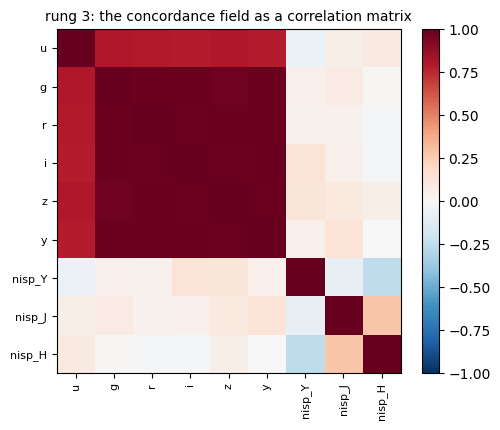

In [8]:
ARCH = REPO/'models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep_sigma.npz'
da = np.load(ARCH, allow_pickle=True)
AB = ['u', 'g', 'r', 'i', 'z', 'y', 'nisp_Y', 'nisp_J', 'nisp_H']
cosd = np.cos(np.deg2rad(np.median(np.asarray(da['i_dec'], float))))

def cluster(xy, r):
    t = cKDTree(xy); pairs = t.query_pairs(r, output_type='ndarray')
    par = np.arange(len(xy))
    def f(a):
        while par[a] != a:
            par[a] = par[par[a]]; a = par[a]
        return a
    for a, b in pairs:
        x, y = f(a), f(b)
        if x != y:
            par[x] = y
    lab = np.array([f(i) for i in range(len(xy))])
    return np.unique(lab, return_inverse=True)[1]

ent = []
for b in AB:
    ra = np.asarray(da[f'{b}_ra'], float); dec = np.asarray(da[f'{b}_dec'], float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    lab = cluster(np.column_stack([ra[ok]*cosd*3600, dec[ok]*3600]), 0.3)
    a = pd.DataFrame(dict(g=lab, ra=ra[ok], dec=dec[ok])).groupby('g').median().reset_index(drop=True)
    a['band'] = b; ent.append(a)
lng = pd.concat(ent, ignore_index=True)
lng['src'] = cluster(np.column_stack([lng.ra*cosd*3600, lng.dec*3600]), 0.4)
lng = lng.drop_duplicates(['src', 'band']).reset_index(drop=True)
posn = lng.groupby('src')[['ra', 'dec']].median()

mc = fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits')[1].data
t_ = cKDTree(np.column_stack([np.asarray(mc['ra'], float)*cosd, np.asarray(mc['dec'], float)]))
dist, idx = t_.query(np.column_stack([posn.ra*cosd, posn.dec]), k=1)
posn['vmag'] = np.where(dist*3600 < 0.5, np.asarray(mc['mag_vis'], float)[idx], np.nan)
gaia = np.load(REPO/'data/gaia_ecdfs_astrometry_cache.npz', allow_pickle=True)
EPOCH = 2024.83; dtp = EPOCH - float(np.asarray(gaia['ref_epoch']).ravel()[0])
gra = np.asarray(gaia['ra'], float)+np.asarray(gaia['pmra'], float)*dtp/3.6e6/cosd
gde = np.asarray(gaia['dec'], float)+np.asarray(gaia['pmdec'], float)*dtp/3.6e6
tg = cKDTree(np.column_stack([np.asarray(gaia['ra'], float)*cosd, np.asarray(gaia['dec'], float)]))
gd, gi = tg.query(np.column_stack([posn.ra*cosd, posn.dec]), k=1)
posn['gaia_i'] = np.where(gd*3600 < 0.5, gi, -1)

gm = lng.join(posn[['vmag', 'gaia_i']], on='src')
gm = gm[(gm.gaia_i >= 0) & (gm.vmag < 19.0)].copy()
gm = gm[np.isfinite(gra[gm.gaia_i]) & np.isfinite(gde[gm.gaia_i])]
gm['bx'] = (gm.ra.values - gra[gm.gaia_i])*cosd*3.6e6
gm['by'] = (gm.dec.values - gde[gm.gaia_i])*3.6e6
piv_bx = gm.pivot_table(index='src', columns='band', values='bx')
piv_by = gm.pivot_table(index='src', columns='band', values='by')
order = [b for b in AB if b in piv_bx.columns]
C_sky = np.nanmean(np.stack([piv_bx[order].corr(min_periods=25).values,
                             piv_by[order].corr(min_periods=25).values]), 0)
off = C_sky[~np.eye(len(order), dtype=bool)]
rub = [i for i, b in enumerate(order) if b in RUBIN_BANDS]
rub_off = C_sky[np.ix_(rub, rub)][~np.eye(len(rub), dtype=bool)]
print(f'real-sky inter-band error correlations (bright Gaia stars, classical positions):')
print(f'  mean off-diag {np.nanmean(off):.2f} | Rubin-Rubin block {np.nanmean(rub_off):.2f} '
      f'(one shared coadd WCS -> ~one vote) | injections gave 0.01')

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(C_sky, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_title('rung 3: the concordance field as a correlation matrix', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig(OUT/'fisher_rung3_realsky.png', dpi=150); plt.show()

## §6 The ladder, assembled

| rung | model of the data | multi-band astrometric gain over VIS | status |
|---|---|---|---|
| 1 — idealized | equal peak SNR, WCS = truth, independent noise | ×5.5 info (7.98 → 3.40 mas) | physics ceiling; reachable by the joint fit *on injections* (§2) |
| 2 — real SEDs | measured per-band amplitudes of real sources | ×2.2 info (×1.47 in σ), carried by VIS + Rubin $gri$ | nb26 census; sets the honest head-v2 target |
| 3 — real sky | + inter-band error correlations (concordance field) | ~0 bright (systematics-shared); ~15% faint via calibrated IV pooling | nb27; bright end conceded to classical by design (paper §5) |

**How to use Fisher in JAISP, in one paragraph.** Compute the analytic pixel CRB whenever
a new measurement question arises — it is exact, free, and every downstream claim must
respect it (Rule 2's tripwire). Immediately re-ask it with realistic signal amplitudes
before quoting any gain (Rule 1). To ask how much of that information a *representation*
retains, never estimate Fisher from realizations — train a decoder and report its
calibrated held-out scatter (Rule 3, §4). To ask how much is *collectible on the sky*,
measure the error-correlation structure against external truth first (§5): on these data
that structure is the concordance field, and it — not the statistical bound — decides the
budget. The same recipe applies verbatim to the next parameters (photometry: $\theta$ =
flux, scale the injection amplitude; shape: $\theta$ = $e_1, e_2$): only the injection
delta changes.

**Where things live:** nb26 = head-v2 feasibility gates (SED census + full ten-stem
decoder bound); nb27 = real-sky pooling and its verdict; paper §5 = the concordance field
that rung 3 re-expresses; `_nb25_outputs/` holds this notebook's figures and summary.

In [9]:
json.dump(dict(
    rung1=dict(vis_crb=float(np.median(1/np.sqrt(F_pix_vis))),
               allband_crb=float(np.median(1/np.sqrt(F_pix_all)))),
    rung2=dict(median_headroom_sigma=float(np.median(headroom))),
    estimators=dict(classical=float(np.nanmedian(sig_cls)), head=float(np.median(sig_head)),
                    joint_fit=float(np.nanmedian(sig_joint)), iv_combo=float(np.nanmedian(sig_combo))),
    rung3=dict(mean_offdiag_rho=float(np.nanmean(off)), rubin_block_rho=float(np.nanmean(rub_off))),
), open(OUT/'fisher_field_guide_summary.json', 'w'), indent=1)
print('saved', OUT/'fisher_field_guide_summary.json')

saved /home/shemmati/Work/Projects/JAISP/io/_nb25_outputs/fisher_field_guide_summary.json
